# Simulacion sistemas punto 3

In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Función 1: y[n] = x[n]/3 + 2x[n-1] - y[n-1]
def sistema1(x):
    y = np.zeros_like(x)
    for n in range(1, len(x)):
        y[n] = (1/3)*x[n] + 2*x[n-1] - y[n-1]
    return y

In [3]:
# Función 2: y[n] = sum_{k=-∞}^n x^2[k]
def sistema2(x):
    y = np.zeros_like(x)
    for n in range(len(x)):
        y[n] = np.sum(x[:n+1]**2)
    return y

In [4]:
# Función 3: y[n] = mediana(x[n-1], x[n], x[n+1])
def sistema3(x):
    y = np.zeros_like(x)
    for n in range(1, len(x)-1):
        y[n] = np.median([x[n-1], x[n], x[n+1]])
    return y

In [5]:
# Función 4: y(t) = A * x(t) + B
def sistema4(x, A=2, B=3):
    return A * x + B

In [6]:
# Señal de prueba
n = np.arange(0, 20)
x = np.zeros_like(n, dtype=float)
x[5:10] = 1
x[10:15] = -1

In [7]:
# Aplicación de los sistemas
y1 = sistema1(x)
y2 = sistema2(x)
y3 = sistema3(x)
y4 = sistema4(x)

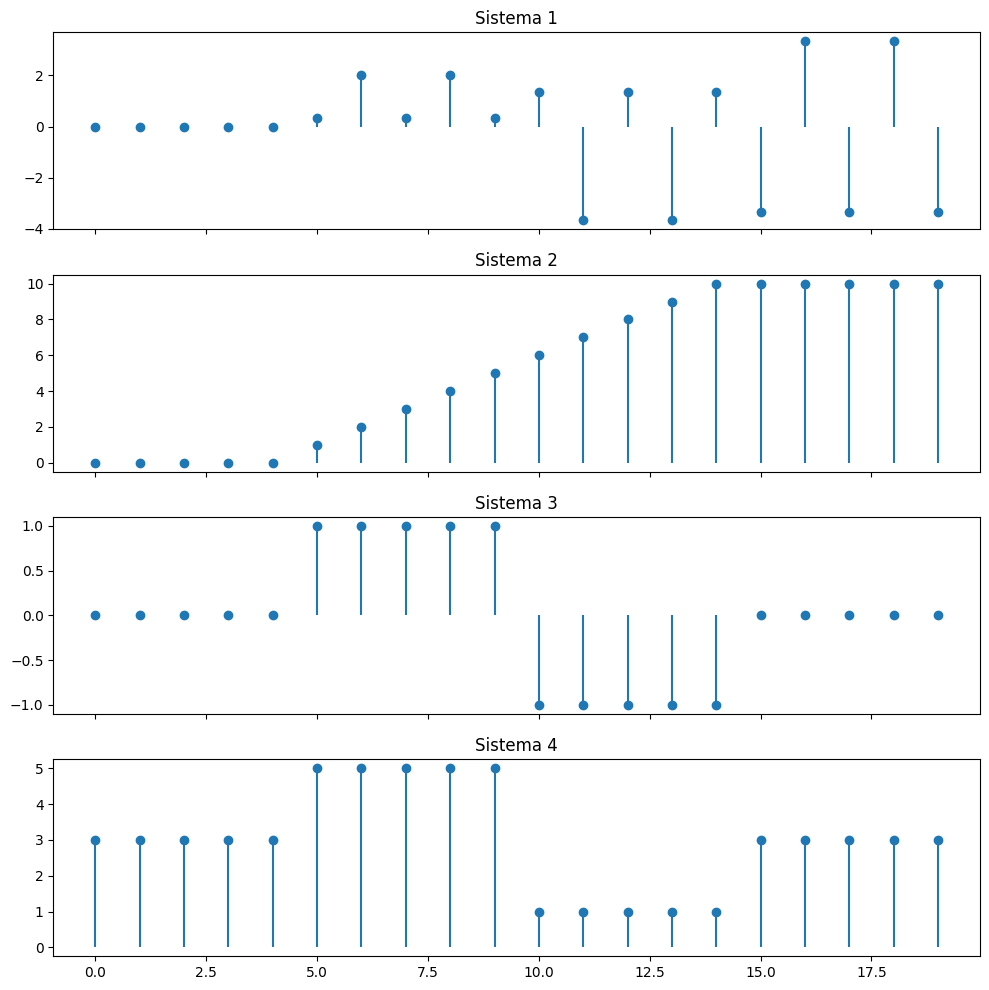

In [8]:
# Gráficas de comparación
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axs[0].stem(n, y1, basefmt=' ')
axs[0].set_title('Sistema 1')
axs[1].stem(n, y2, basefmt=' ')
axs[1].set_title('Sistema 2')
axs[2].stem(n, y3, basefmt=' ')
axs[2].set_title('Sistema 3')
axs[3].stem(n, y4, basefmt=' ')
axs[3].set_title('Sistema 4')
plt.tight_layout()
plt.show()

# Pregunta 4 - Convolución Discreta y Respuesta desde Escalón

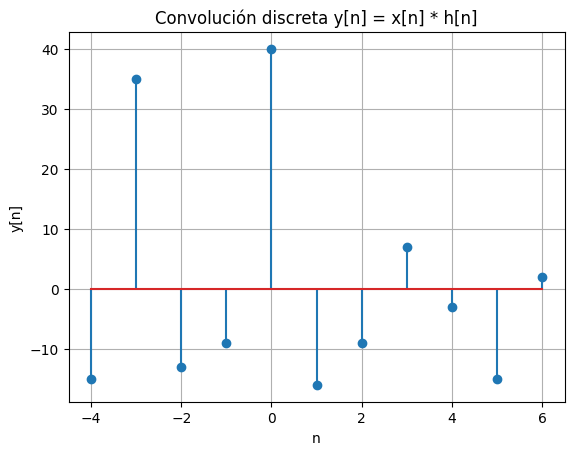

Salida y[n]: [-15  35 -13  -9  40 -16  -9   7  -3 -15   2]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Señales de entrada
x = np.array([-15, 5, -3, 0, 5, 7, -1])
h = np.array([1, -2, 0, 1, -2])

# n=0 está en el índice 2 para x, y en el índice 2 para h
# Convolución discreta
y = np.convolve(x, h)

# Ejes temporales
n_x = np.arange(-2, -2 + len(x))  # porque -3 está en n=0
n_h = np.arange(-2, -2 + len(h))  # porque 0 está en n=0
n_y = np.arange(n_x[0] + n_h[0], n_x[-1] + n_h[-1] + 1)

# Mostrar resultado
plt.stem(n_y, y)
plt.title("Convolución discreta y[n] = x[n] * h[n]")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.show()

print("Salida y[n]:", y)

In [ ]:

# Funciones desde el cuaderno original de convolución
def convgraf(h,x):
   lx = len(x)
   lh = len(h)
   M = 2*lx+lh
   xm = np.zeros((M,M))
   hm = np.r_[np.zeros((lx,1)),h,np.zeros((lx,1))]
   ym = np.zeros((M,M))
   for i in range(M-lx+1):
     xm[i:i+lx,i] = np.flip(x).reshape(-1)
     ym[i,i] = xm[:,i].T.dot(hm)
   return xm, ym, hm

def plot_conv(k,xm,ym,hm):
     plt.stem(xm[:,k],markerfmt='+',label='$x[k]$')
     plt.stem(hm,linefmt='g',markerfmt='.',label='$h[n-k]$')
     plt.stem(ym[:k,:].sum(axis=0),markerfmt='s',linefmt='r',label='$y[n]=\sum x[k]h[n-k]$')
     plt.legend()
     plt.show()
     return

xm, ym, hm = convgraf(h.reshape(-1,1), x.reshape(-1,1))

@interact(k=(0, xm.shape[0]-len(x), 1))
def show_frame(k=0):
    plot_conv(k,xm,ym,hm)


/tmp/ipython-input-10-1733474479.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ym[i,i] = xm[:,i].T.dot(hm)


interactive(children=(IntSlider(value=0, description='k', max=12), Output()), _dom_classes=('widget-interact',…

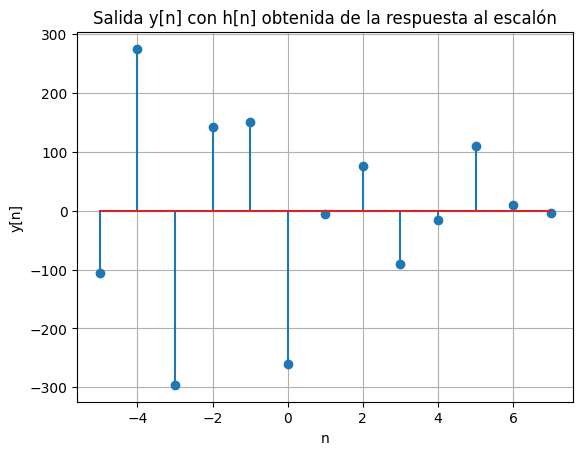

Nueva salida y[n] con h obtenida de escalón: [-105  275 -296  143  151 -260   -6   76  -91  -15  110    9   -3]


In [ ]:
# Parte 2: Convolución con respuesta obtenida desde escalón

hu = np.array([-1, 6, -10, 3, 1, -10, 2, 5])
h_from_step = np.diff(hu)

y2 = np.convolve(x, h_from_step)

n_h2 = np.arange(-3, -3 + len(h_from_step))  # porque 3 está en n=0
n_y2 = np.arange(n_x[0] + n_h2[0], n_x[-1] + n_h2[-1] + 1)

plt.stem(n_y2, y2)
plt.title("Salida y[n] con h[n] obtenida de la respuesta al escalón")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.show()

print("Nueva salida y[n] con h obtenida de escalón:", y2)

#Pregunta 5 - Salida sistema serie


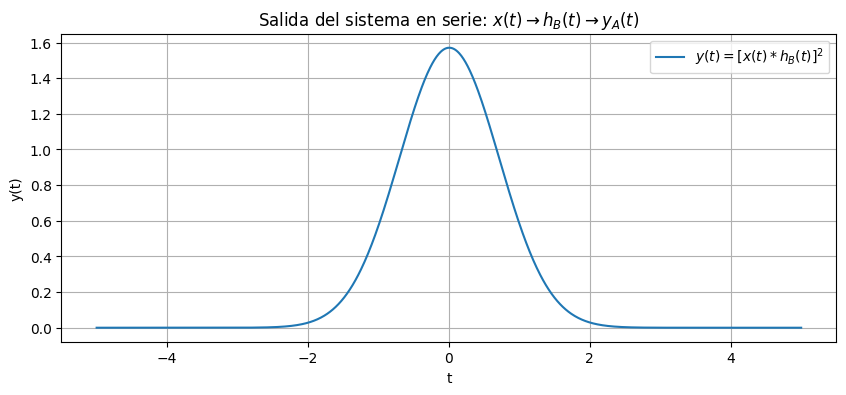

In [9]:
#@title a) Convolución x(t) * h_B(t) → cuadrado del resultado
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# Parámetros
a = 1.0
b = 1.0
B = 1.0
t = np.linspace(-5, 5, 1000)
dt = t[1] - t[0]

# Señales
x_t = np.exp(-a * t**2)
hB_t = B * np.exp(-b * t**2)

# Convolución
conv = convolve(x_t, hB_t, mode='same') * dt
y_t = conv**2

# Graficar resultados
plt.figure(figsize=(10, 4))
plt.plot(t, y_t, label='$y(t) = [x(t) * h_B(t)]^2$')
plt.title("Salida del sistema en serie: $x(t) \\rightarrow h_B(t) \\rightarrow y_A(t)$")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()


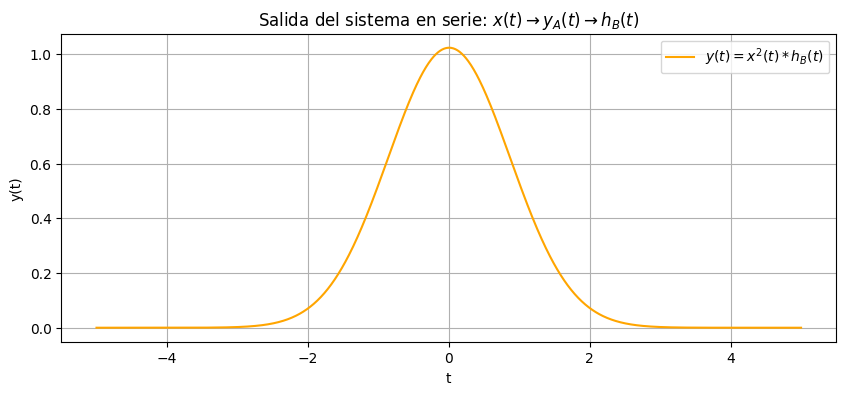

In [10]:
#@title b) Elevar x(t) al cuadrado → convolución con h_B(t)
# Cuadrado de la señal de entrada
x2_t = x_t**2

# Convolución con h_B(t)
y_t_b = convolve(x2_t, hB_t, mode='same') * dt

# Graficar resultados
plt.figure(figsize=(10, 4))
plt.plot(t, y_t_b, label='$y(t) = x^2(t) * h_B(t)$', color='orange')
plt.title("Salida del sistema en serie: $x(t) \\rightarrow y_A(t) \\rightarrow h_B(t)$")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()


#Pregunta 8 - Demostracion Laplace

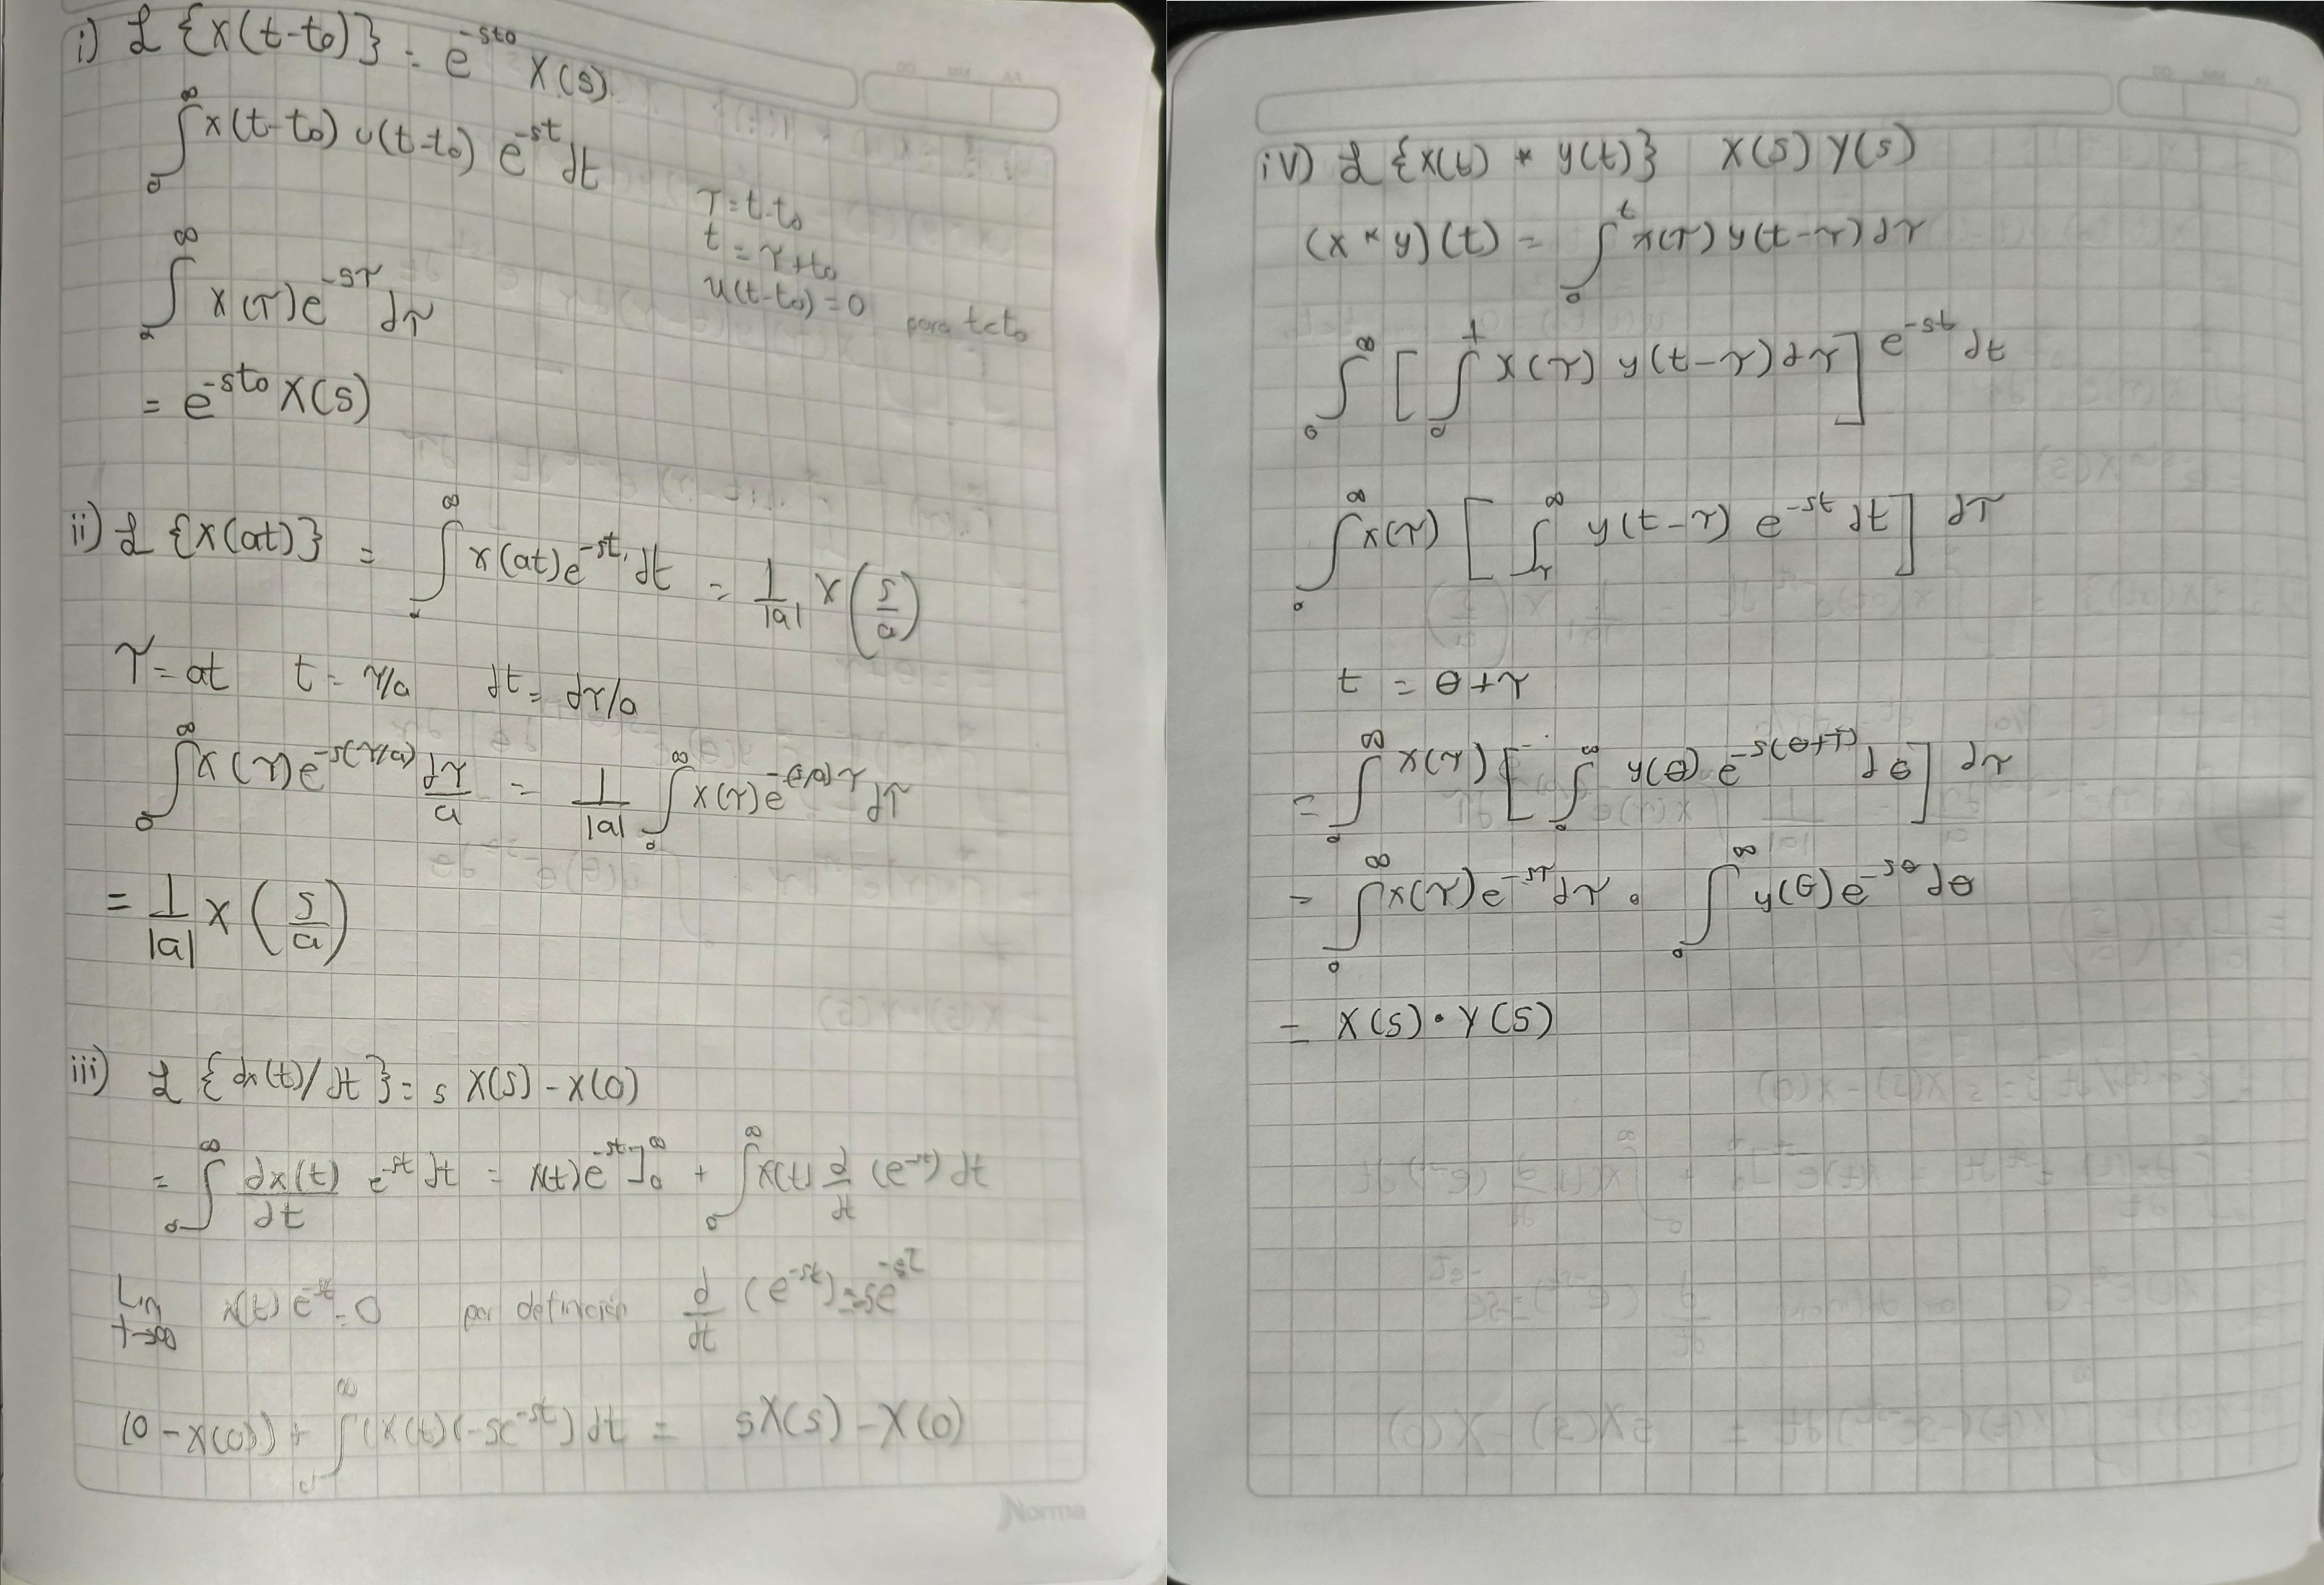

#Pregunta 9 - Polos y Ceros


## i)
$[
x_1(t) = e^{-2t}u(t) + e^{-3t}u(t)
$]


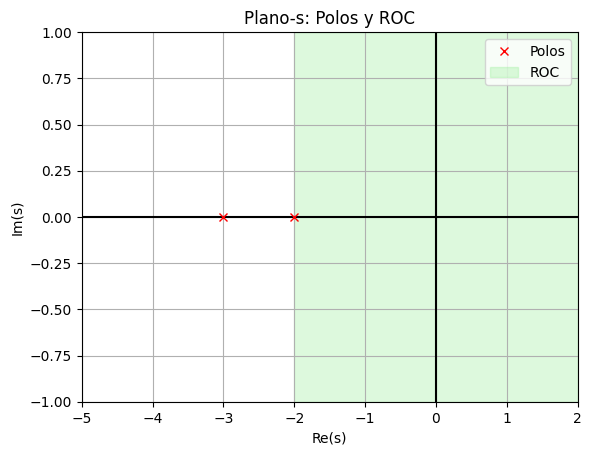

In [11]:
import matplotlib.pyplot as plt

# Crear plano-s
fig, ax = plt.subplots()
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Polos en s = -2 y s = -3
ax.plot([-2, -3], [0, 0], 'rx', label='Polos')

# ROC: Re(s) > -2
ax.fill_betweenx([-1, 1], -2, 2, color='lightgreen', alpha=0.3, label='ROC')

# Formato
ax.set_xlim(-5, 2)
ax.set_ylim(-1, 1)
ax.set_xlabel('Re(s)')
ax.set_ylabel('Im(s)')
ax.set_title('Plano-s: Polos y ROC')
ax.legend()
plt.grid()
plt.show()


## ii)
$[
x_2(t) = e^{2t}u(t) + e^{-3t}u(-t)
$]


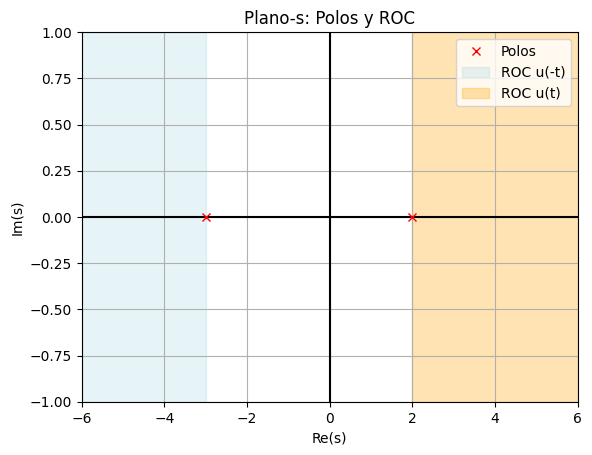

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Polos en s = 2 y s = -3
ax.plot([2, -3], [0, 0], 'rx', label='Polos')

# ROC para e^{-3t}u(-t): Re(s) < -3
ax.fill_betweenx([-1, 1], -10, -3, color='lightblue', alpha=0.3, label='ROC u(-t)')

# ROC para e^{2t}u(t): Re(s) > 2
ax.fill_betweenx([-1, 1], 2, 10, color='orange', alpha=0.3, label='ROC u(t)')

# Formato
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 1)
ax.set_xlabel('Re(s)')
ax.set_ylabel('Im(s)')
ax.set_title('Plano-s: Polos y ROC')
ax.legend()
plt.grid()
plt.show()


## iii)
$[
x_3(t) = e^{-a|t|}
$]


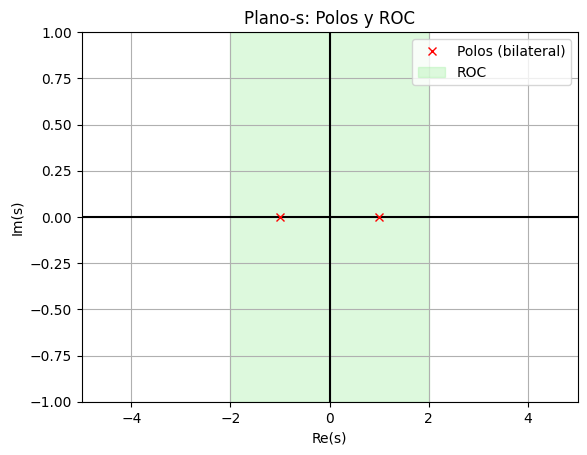

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Polo doble en s = -a y s = a
ax.plot([-a, a], [0, 0], 'rx', label='Polos (bilateral)')

# ROC: -a < Re(s) < a
a = 2  # puedes cambiar a cualquier valor positivo
ax.fill_betweenx([-1, 1], -a, a, color='lightgreen', alpha=0.3, label='ROC')

# Formato
ax.set_xlim(-a-3, a+3)
ax.set_ylim(-1, 1)
ax.set_xlabel('Re(s)')
ax.set_ylabel('Im(s)')
ax.set_title('Plano-s: Polos y ROC')
ax.legend()
plt.grid()
plt.show()


## iv)
$[
x_4(t) = e^{-2t} [u(t) - u(t - 5)]
$]


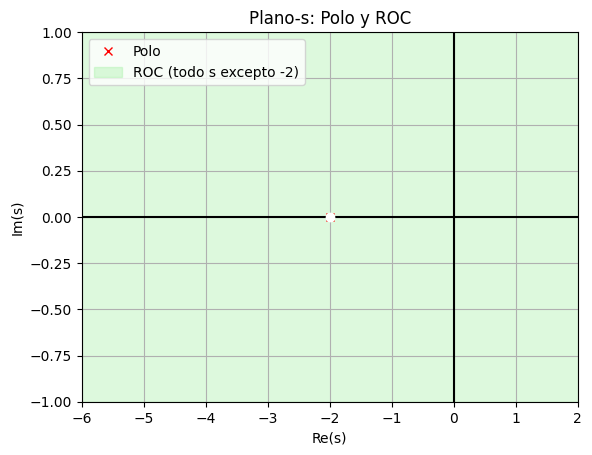

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.axhline(0, color='black')
ax.axvline(0, color='black')

# Polo en s = -2
ax.plot([-2], [0], 'rx', label='Polo')

# ROC: todo el plano excepto s = -2 (señal de duración finita)
ax.fill_betweenx([-1, 1], -10, 10, color='lightgreen', alpha=0.3, label='ROC (todo s excepto -2)')
ax.plot([-2], [0], 'w.', markersize=12)  # punto blanco sobre el polo para indicar que no pertenece a la ROC

# Formato
ax.set_xlim(-6, 2)
ax.set_ylim(-1, 1)
ax.set_xlabel('Re(s)')
ax.set_ylabel('Im(s)')
ax.set_title('Plano-s: Polo y ROC')
ax.legend()
plt.grid()
plt.show()


# Pregunta 12 Funcion de Transferencia

Función de transferencia en lazo abierto para un circuito RLC serie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 11.7 MB/s eta 0:00:00
Función simbólica:


1/(C*s*(L*s + R) + 1)

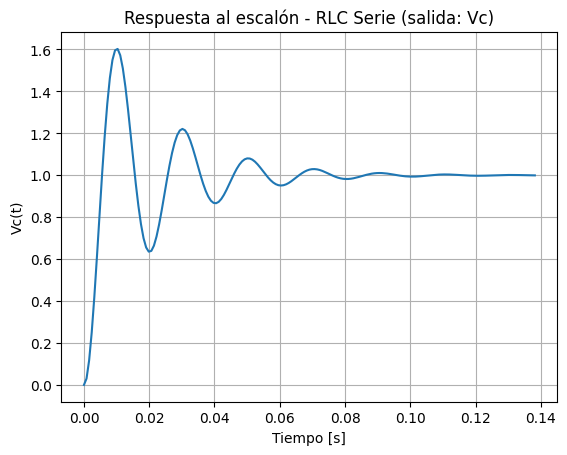

In [3]:
# Instalar librería si no está disponible
!pip install control

# Librerías
import sympy as sp
import control as ctl
import matplotlib.pyplot as plt

# Definir símbolos simbólicos
s = sp.Symbol('s')
R, L, C = sp.symbols('R L C')

# Impedancia total del RLC en serie
Z_total = R + L*s + 1/(C*s)

# Función de transferencia Vc/Vin
H1 = (1/(C*s)) / Z_total
H1_simplificada = sp.simplify(H1)

print("Función simbólica:")
display(H1_simplificada)

# Parámetros reales para simulación
R_val = 10       # Ohm
L_val = 0.1      # H
C_val = 100e-6   # F

# Numerador y denominador para sistema
num = [1]
den = [L_val*C_val, R_val*C_val, 1]

# Sistema en lazo abierto
sistema1 = ctl.TransferFunction(num, den)

# Respuesta al escalón
t, y = ctl.step_response(sistema1)

# Gráfico
plt.plot(t, y)
plt.title("Respuesta al escalón - RLC Serie (salida: Vc)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Vc(t)")
plt.grid(True)
plt.show()


Función de transferencia Circuito RCL en paralelo

Función simbólica de transferencia (RCL paralelo):


R/(C*L*R*s**2 + L*s + R)

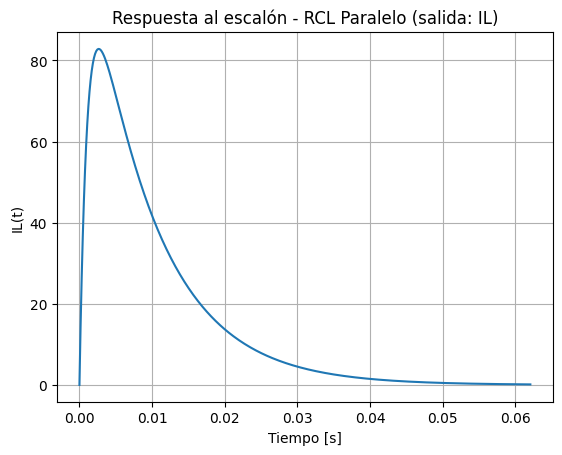

In [4]:
# Instalar la librería control si no está instalada
!pip install control

# Importar librerías
import sympy as sp
import control as ctl
import matplotlib.pyplot as plt

# Definir variables simbólicas
s = sp.Symbol('s')
R, L, C = sp.symbols('R L C')

# Admitancias de cada rama del circuito paralelo
Y_R = 1/R
Y_L = 1/(L*s)
Y_C = C*s

# Admitancia total
Y_total = Y_R + Y_L + Y_C

# Función de transferencia IL(s)/Iin(s)
H2 = Y_L / Y_total
H2_simplificada = sp.simplify(H2)

print("Función simbólica de transferencia (RCL paralelo):")
display(H2_simplificada)

# Valores para simulación numérica
R_val = 10       # Ohmios
L_val = 0.1      # Henrios
C_val = 100e-6   # Faradios

# Numerador y denominador de la función de transferencia
num = [1, 0]
den = [L_val*C_val, L_val/R_val + C_val, 1]

# Crear sistema de control
sistema2 = ctl.TransferFunction(num, den)

# Respuesta al escalón
t, y = ctl.step_response(sistema2)

# Graficar
plt.plot(t, y)
plt.title("Respuesta al escalón - RCL Paralelo (salida: IL)")
plt.xlabel("Tiempo [s]")
plt.ylabel("IL(t)")
plt.grid(True)
plt.show()


#Pregunta 13 - Salida en Tiempo

RLC serie

🔸 Impulso - y(t):


225.017580185205*exp(-50.0*t)*sin(444.409720865779*t)*Heaviside(t)

🔸 Escalón - y(t):


(-0.0562543950463012*exp(-50.0*t)*sin(444.409720865779*t) - 0.5*exp(-50.0*t)*cos(444.409720865779*t))*Heaviside(t) + 0.5*Heaviside(t)

🔸 Rampa - y(t):


0.5*t*Heaviside(t) + (-0.00109696070340287*exp(-50.0*t)*sin(444.409720865779*t) + 0.00025*exp(-50.0*t)*cos(444.409720865779*t))*Heaviside(t) - 0.00025*Heaviside(t)

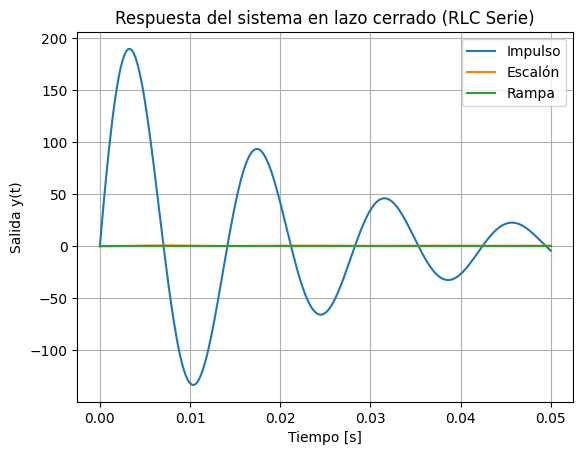

In [5]:
# Instalar librerías necesarias
!pip install control

# Importar librerías
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Definir variables simbólicas
s, t = sp.symbols('s t')
R, L, C = sp.symbols('R L C', positive=True, real=True)

# Función de transferencia RLC serie (en lazo abierto): Vc(s)/Vin(s)
H_open = (1/(C*s)) / (R + L*s + 1/(C*s))
H_open = sp.simplify(H_open)

# Función de transferencia en lazo cerrado
H_closed = H_open / (1 + H_open)
H_closed = sp.simplify(H_closed)

# Entradas y sus transformadas
entradas = {
    "Impulso": 1,
    "Escalón": 1/s,
    "Rampa": 1/s**2
}

# Valores para simulación numérica
valores = {R: 10, L: 0.1, C: 100e-6}

# Generar y graficar cada respuesta
for nombre, Xs in entradas.items():
    Ys = sp.simplify(H_closed * Xs)
    yt = sp.inverse_laplace_transform(Ys.subs(valores), s, t)

    # Mostrar expresión simbólica
    print(f"🔸 {nombre} - y(t):")
    display(yt)

    # Convertir a función numérica
    yt_func = sp.lambdify(t, yt, 'numpy')

    # Tiempo para graficar
    tiempo = np.linspace(0, 0.05, 500)
    salida = yt_func(tiempo)

    # Graficar
    plt.plot(tiempo, salida, label=nombre)

# Gráfico final
plt.title("Respuesta del sistema en lazo cerrado (RLC Serie)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida y(t)")
plt.legend()
plt.grid(True)
plt.show()


RLC Paralelo

🔸 Impulso - y(t):


447.213595499958*exp(-500.0*t)*sinh(223.606797749979*t)*Heaviside(t)

🔸 Escalón - y(t):


10*(-0.11180339887499*exp(-500.0*t)*sinh(223.606797749979*t) - 0.05*exp(-500.0*t)*cosh(223.606797749979*t))*Heaviside(t) + 0.5*Heaviside(t)

🔸 Rampa - y(t):


0.5*t*Heaviside(t) + 10*(0.000335410196624969*exp(-500.0*t)*sinh(223.606797749979*t) + 0.00025*exp(-500.0*t)*cosh(223.606797749979*t))*Heaviside(t) - 0.0025*Heaviside(t)

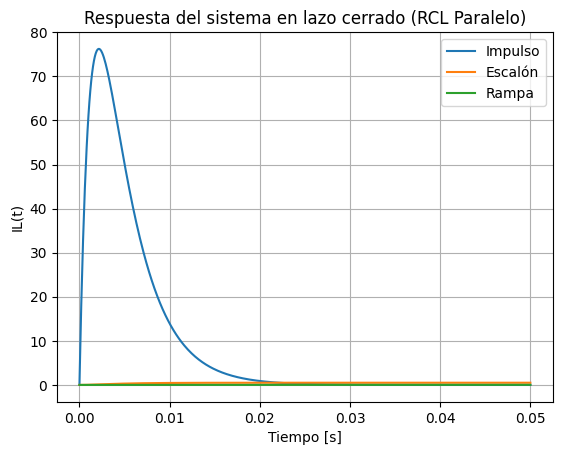

In [7]:
# Instalar librería si no está instalada
!pip install control

# Importar librerías necesarias
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Definir variables simbólicas
s, t = sp.symbols('s t')
R, L, C = sp.symbols('R L C', positive=True, real=True)

# Función de transferencia en lazo abierto: IL(s)/Iin(s) para RCL paralelo
Y_R = 1/R
Y_L = 1/(L*s)
Y_C = C*s
Y_total = Y_R + Y_L + Y_C

H_open_parallel = Y_L / Y_total
H_open_parallel = sp.simplify(H_open_parallel)

# Función en lazo cerrado
H_closed_parallel = H_open_parallel / (1 + H_open_parallel)
H_closed_parallel = sp.simplify(H_closed_parallel)

# Transformadas de las entradas
entradas = {
    "Impulso": 1,
    "Escalón": 1/s,
    "Rampa": 1/s**2
}

# Valores numéricos
valores = {R: 10, L: 0.1, C: 100e-6}

# Evaluar y graficar respuestas
for nombre, Xs in entradas.items():
    Ys = sp.simplify(H_closed_parallel * Xs)
    yt = sp.inverse_laplace_transform(Ys.subs(valores), s, t)

    # Mostrar respuesta simbólica
    print(f"🔸 {nombre} - y(t):")
    display(yt)

    # Función numérica para graficar
    yt_func = sp.lambdify(t, yt, 'numpy')

    # Rango de tiempo
    tiempo = np.linspace(0, 0.05, 500)
    salida = yt_func(tiempo)

    # Graficar
    plt.plot(tiempo, salida, label=nombre)

# Gráfico final
plt.title("Respuesta del sistema en lazo cerrado (RCL Paralelo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("IL(t)")
plt.grid(True)
plt.legend()
plt.show()
